<a href="https://colab.research.google.com/github/zulvikert/prakte-git-hub/blob/main/2411412020_Muhammad_Zulvi_Prawira_Tugas1_Pemrogaman_Paralel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Soal 1. Klasifikasi FLynn: Untuk masing-masing skenario berikut, tentukan kategori Flynn (SISD/SIMD/MISD/MIMD) beserta alasannya:
*   Operasi arr + arr pada NumPy array
*   Program Python biasa (tanpa threading/multiprocessing) yang membaca file lalu memproses baris demi baris
*   Cluster komputer yang masing-masing node menjalankan simulasi cuaca berbeda untuk wilayah berbeda secara independen

Jawaban:


*   Operasi arr + arr pada NumPy array: SIMD (Single Instruction, Multiple Data)

Alasan: Memanggil satu instruksi penjumlahan (vectorized operation) yang dieksekusi secara sejajar pada banyak elemen data (elemen-elemen array) sekaligus.
*   Program Python biasa (tanpa threading/multiprocessing) yang membaca file lalu memproses baris demi baris: SISD (Single Instruction, Single Data)

Alasan: Berjalan pada satu core secara sekuensial (tunggal), mengeksekusi satu aliran instruksi untuk memproses satu data per baris secara berurutan.

*   Cluster komputer yang masing-masing node menjalankan simulasi cuaca berbeda untuk wilayah berbeda secara independen: MIMD (Multiple Instruction, Multiple Data)

Alasan: Setiap node bekerja secara independen dengan instruksi/aliran program tersendiri untuk memproses himpunan data (wilayah) yang berbeda pula.



Soal 2. Analisis Amdahl: Sebuah aplikasi pengolahan citra memiliki proporsi paralel $P = 0{,}85$.

*   Hitung speedup teoritis untuk $N = 2, 4, 8, 16, 32, 64$ (gunakan fungsi amdahl_speedup di atas)
*   Buat plot speedup vs N
*   Pada N berapa penambahan prosesor mulai memberikan manfaat yang sangat kecil ("diminishing returns")? Jelaskan alasan kalian.

Jawaban:

Rumus Hukum Amdahl:$$S(N) = \frac{1}{(1 - P) + \frac{P}{N}} = \frac{1}{0{,}15 + \frac{0{,}85}{N}}$$Perhitungan Speedup Teoritis:

$N = 2 \implies S = \frac{1}{0{,}15 + 0{,}425} \approx \mathbf{1{,}74\times}$

$N = 4 \implies S = \frac{1}{0{,}15 + 0{,}2125} \approx \mathbf{2{,}76\times}$

$N = 8 \implies S = \frac{1}{0{,}15 + 0{,}10625} \approx \mathbf{3{,}90\times}$

$N = 16 \implies S = \frac{1}{0{,}15 + 0{,}053125} \approx \mathbf{4{,}92\times}$

$N = 32 \implies S = \frac{1}{0{,}15 + 0{,}0265625} \approx \mathbf{5{,}66\times}$

$N = 64 \implies S = \frac{1}{0{,}15 + 0{,}01328125} \approx \mathbf{6{,}12\times}$(Batas maksimum teoritis $N \to \infty$ adalah $6{,}67\times$)



N Processors | Speedup Teoritis
------------------------------
           2 | 1.74x
           4 | 2.76x
           8 | 3.90x
          16 | 4.92x
          32 | 5.66x
          64 | 6.12x


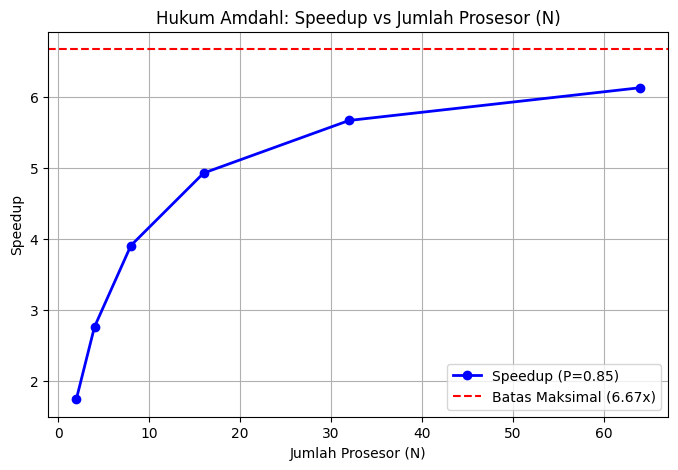

In [1]:
import matplotlib.pyplot as plt

def amdahl_speedup(P, N):
    return 1 / ((1 - P) + (P / N))

P = 0.85
N_values = [2, 4, 8, 16, 32, 64]
speedups = [amdahl_speedup(P, n) for n in N_values]

# Cetak Tabel Speedup
print("N Processors | Speedup Teoritis")
print("-" * 30)
for n, s in zip(N_values, speedups):
    print(f"{n:12d} | {s:.2f}x")

# Plot Speedup vs N
plt.figure(figsize=(8, 5))
plt.plot(N_values, speedups, marker='o', color='b', linewidth=2, label='Speedup (P=0.85)')
plt.axhline(y=1/(1-P), color='r', linestyle='--', label=f'Batas Maksimal ({1/(1-P):.2f}x)')
plt.title('Hukum Amdahl: Speedup vs Jumlah Prosesor (N)')
plt.xlabel('Jumlah Prosesor (N)')
plt.ylabel('Speedup')
plt.grid(True)
plt.legend()
plt.show()

Analisis Diminishing Returns:

Penambahan prosesor mulai memberikan manfaat yang sangat kecil pada $N = 16$ hingga $N = 32$.

Alasan:

Komponen sekuensial ($1 - P = 0{,}15$) mulai mendominasi batas atas speedup. Kenaikan dari $N=2$ ke $N=4$ memberikan tambahan speedup sebesar $+1{,}28\times$, sedangkan dari $N=32$ ke $N=64$ hanya menambah $+0{,}46\times$ meskipun jumlah prosesor digandakan 2 kali lipat.

Soal 3. Benchmark Mandiri: Ambil salah satu fungsi CPU-bound buatan sendiri (boleh modifikasi hitung_prima, atau buat fungsi lain seperti menghitung deret Fibonacci naif secara rekursif). Ukur waktu eksekusinya untuk minimal 4 ukuran input berbeda menggunakan time.perf_counter() dan timeit, lalu bandingkan hasil keduanya dalam satu tabel/plot.

Jawaban:

Ukuran Input | perf_counter() (s) | timeit() (s)
---------------------------------------------
          30 |             0.3393 |     0.3339
          32 |             0.9149 |     0.8699
          34 |             1.2808 |     1.2353
          35 |             2.0662 |     2.0123


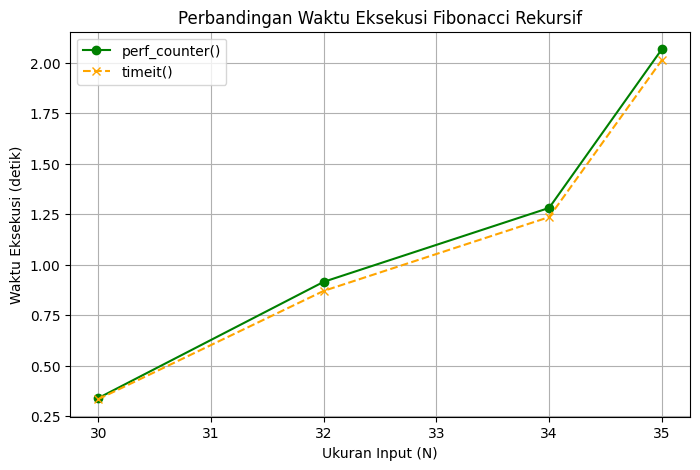

In [2]:
import time
import timeit
import matplotlib.pyplot as plt

# Fungsi CPU-bound: Fibonacci Rekursif Naif
def fibonacci(n):
    if n <= 1:
        return n
    return fibonacci(n - 1) + fibonacci(n - 2)

input_sizes = [30, 32, 34, 35]
time_perf = []
time_timeit = []

for size in input_sizes:
    # Pengukuran menggunakan time.perf_counter()
    start = time.perf_counter()
    fibonacci(size)
    end = time.perf_counter()
    time_perf.append(end - start)

    # Pengukuran menggunakan timeit.timeit()
    t = timeit.timeit(lambda: fibonacci(size), number=1)
    time_timeit.append(t)

# Menampilkan Tabel Perbandingan
print("Ukuran Input | perf_counter() (s) | timeit() (s)")
print("-" * 45)
for size, t_perf, t_timeit in zip(input_sizes, time_perf, time_timeit):
    print(f"{size:12d} | {t_perf:18.4f} | {t_timeit:10.4f}")

# Plot Perbandingan Waktu Eksekusi
plt.figure(figsize=(8, 5))
plt.plot(input_sizes, time_perf, marker='o', label='perf_counter()', color='green')
plt.plot(input_sizes, time_timeit, marker='x', linestyle='--', label='timeit()', color='orange')
plt.title('Perbandingan Waktu Eksekusi Fibonacci Rekursif')
plt.xlabel('Ukuran Input (N)')
plt.ylabel('Waktu Eksekusi (detik)')
plt.grid(True)
plt.legend()
plt.show()

Soal 4. Refleksi Singkat (maks. 150 kata): Menurut kalian, kapan Hukum Amdahl lebih relevan digunakan dibanding Hukum Gustafson, dan sebaliknya? Berikan satu contoh kasus nyata untuk masing-masing.

Jawaban:

Hukum Amdahl lebih relevan digunakan pada sistem dengan ukuran beban kerja tetap (fixed workload), di mana fokus utamanya adalah mempercepat durasi penyelesaian tugas yang sama menggunakan lebih banyak prosesor. Contohnya: merender satu frame gambar 3D beresolusi $1080\text{p}$ tertentu pada perangkat lunak animasi.

Sebaliknya, Hukum Gustafson lebih relevan pada sistem dengan skala beban kerja fleksibel (scaled workload), di mana penambahan prosesor dimanfaatkan untuk menyelesaikan beban komputasi yang lebih besar dalam rentang waktu yang sama. Contohnya: simulasi prakiraan cuaca global, di mana penambahan node cluster digunakan untuk meningkatkan kerapatan resolusi kisi (grid resolution) wilayah simulasi, bukan sekadar mempercepat waktu jalan